In [ ]:

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)


## Load the dataset

In [ ]:
df = pd.read_csv('/content/tweet_emotions.csv')
df = df.rename(columns={'content': 'text', 'sentiment': 'label'})
df.head()


,tweet_id,label,text
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In [ ]:
print(df.shape)
print(df['label'].value_counts())


(40000, 3)
label
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


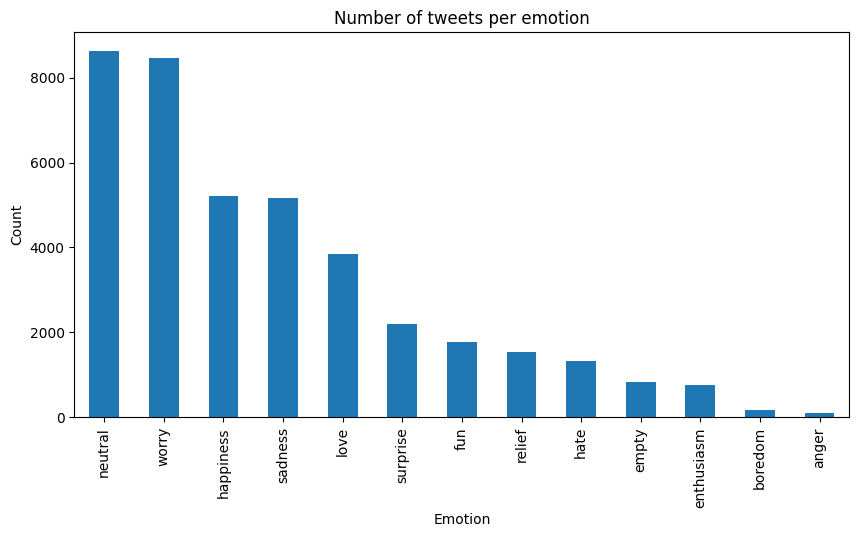

In [ ]:
df['label'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Number of tweets per emotion')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()


,text,clean_text
0,@tiffanylue i know i was listenin to bad habi...,know listenin bad habit earlier started freaki...
1,Layin n bed with a headache ughhhh...waitin o...,layin n bed headache ughhhhwaitin call
2,Funeral ceremony...gloomy friday...,funeral ceremonygloomy friday
3,wants to hang out with friends SOON!,wants hang friends soon
4,@dannycastillo We want to trade with someone w...,want trade someone houston tickets one


In [ ]:

df = df[df['clean_text'].str.strip() != ""]
df = df.reset_index(drop=True)
print(df.shape)


(39786, 4)


## Encode labels

In [ ]:
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

num_classes = len(le.classes_)
print("Number of classes:", num_classes)
print(list(le.classes_))


Number of classes: 13
['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']


## Split into train and test

In [ ]:
X = df['clean_text'].values
y = df['label_id'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 31828
Test size: 7958


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report # Ensure these are imported if not globally available

vectorizer = TfidfVectorizer(
    max_features=50000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)
X_train_text = vectorizer.fit_transform(X_train)
X_test_text = vectorizer.transform(X_test)

svc = LinearSVC(class_weight='balanced', random_state=42, C=0.5)
svc.fit(X_train_text, y_train)
y_pred = svc.predict(X_test_text)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.24604171902488062
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.02      0.08      0.04        39
           2       0.04      0.11      0.06       152
           3       0.03      0.07      0.04       160
           4       0.11      0.15      0.12       393
           5       0.28      0.26      0.27      1044
           6       0.17      0.32      0.22       274
           7       0.39      0.43      0.41       793
           8       0.36      0.23      0.28      1686
           9       0.11      0.18      0.14       306
          10       0.30      0.27      0.29      1003
          11       0.11      0.13      0.12       431
          12       0.37      0.24      0.29      1662

    accuracy                           0.25      7958
   macro avg       0.18      0.19      0.18      7958
weighted avg       0.29      0.25      0.26      7958



## Convert text to numbers (tokenize + pad)

In [ ]:
VOCAB_SIZE = 10000
MAX_LEN = 20

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(X_train_pad[0])
print(y_train[0])


[ 44  50 165   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
12


In [ ]:
EMBED_DIM = 64
NUM_HEADS = 2
FF_DIM = 64

def build_model():
    inputs = layers.Input(shape=(MAX_LEN,))


    token_emb = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM)(inputs)


    positions = tf.range(start=0, limit=MAX_LEN, delta=1)
    pos_emb = layers.Embedding(input_dim=MAX_LEN, output_dim=EMBED_DIM)(positions)

    x = token_emb + pos_emb


    attn_output = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=EMBED_DIM)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn_output = layers.Dense(FF_DIM, activation="relu")(x)
    ffn_output = layers.Dense(EMBED_DIM)(ffn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 20, 64)    │    640,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 20, 64)    │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     33,216 │ add_3[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 20, 64)    │          0 │ add_3[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 20, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 20, 64)    │      4,160 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      4,160 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 13)        │        845 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 686,797 (2.62 MB)

 Trainable params: 686,797 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and train the model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32
)


Epoch 1/10
995/995 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.2949 - loss: 2.0356 - val_accuracy: 0.3474 - val_loss: 1.9077
Epoch 2/10
995/995 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - accuracy: 0.3897 - loss: 1.8163 - val_accuracy: 0.3462 - val_loss: 1.9212
Epoch 3/10
995/995 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.4558 - loss: 1.6246 - val_accuracy: 0.3285 - val_loss: 2.0729
Epoch 4/10
995/995 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.5315 - loss: 1.4062 - val_accuracy: 0.3049 - val_loss: 2.3775
Epoch 5/10
995/995 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.5984 - loss: 1.2069 - val_accuracy: 0.2952 - val_loss: 2.7390
Epoch 6/10
995/995 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.6434 - loss: 1.0696 - val_accuracy: 0.2912 - val_loss: 3.1939
Epoch 7/10
995/995 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.6634 - loss: 0.9878 - val_accuracy: 0.2924 - val_loss: 3.5062
Epoch 8/10
995/995 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.6789 - loss: 0.9378 - 

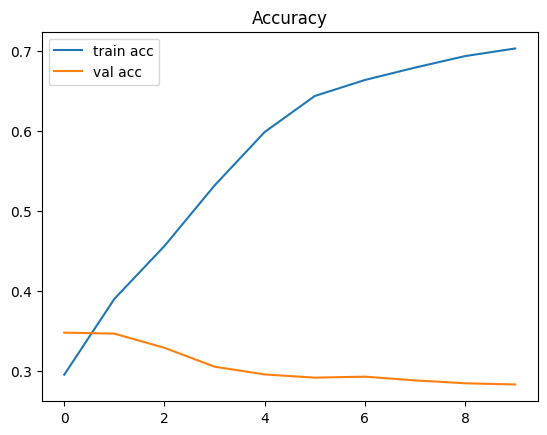

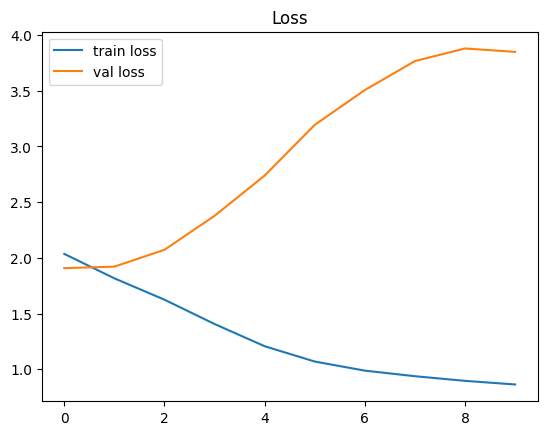

In [ ]:
# plot accuracy and loss
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()


## Evaluate the model

In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test loss:", loss)
print("Test accuracy:", acc)


249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2826 - loss: 3.8486
Test loss: 3.8485968112945557
Test accuracy: 0.28260868787765503


In [ ]:
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        15
     boredom       0.00      0.00      0.00        39
       empty       0.02      0.01      0.01       152
  enthusiasm       0.03      0.01      0.02       160
         fun       0.11      0.05      0.06       393
   happiness       0.30      0.28      0.29      1044
        hate       0.26      0.19      0.22       274
        love       0.35      0.41      0.38       793
     neutral       0.32      0.40      0.36      1686
      relief       0.13      0.08      0.09       306
     sadness       0.25      0.36      0.30      1003
    surprise       0.12      0.07      0.09       431
       worry       0.30      0.28      0.29      1662

    accuracy                           0.28      7958
   macro avg       0.17      0.16      0.16      7958
weighted avg       0.26      0.28      0.27      7958



In [ ]:
EMBED_DIM = 64
NUM_HEADS = 2
FF_DIM = 64

def build_model_with_more_dropout():
    inputs = layers.Input(shape=(MAX_LEN,))

    token_emb = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM)(inputs)

    positions = tf.range(start=0, limit=MAX_LEN, delta=1)
    pos_emb = layers.Embedding(input_dim=MAX_LEN, output_dim=EMBED_DIM)(positions)

    x = token_emb + pos_emb

    attn_output = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=EMBED_DIM)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn_output = layers.Dense(FF_DIM, activation="relu")(x)
    ffn_output = layers.Dense(EMBED_DIM)(ffn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x) # Existing dropout layer

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x) # New dropout layer added here
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    return model

